In [3]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,  DataLoader, random_split
import random
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Sun May  3 16:17:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
embedding_model = SentenceTransformer("all-mpnet-base-v2", device='cuda')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
dataset = load_dataset("Anthropic/hh-rlhf")

README.md: 0.00B [00:00, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

helpful-rejection-sampled/train.jsonl.gz:   0%|          | 0.00/25.7M [00:00<?, ?B/s]

...

helpful-base/test.jsonl.gz:   0%|          | 0.00/875k [00:00<?, ?B/s]

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

In [ ]:
full_train = dataset["train"]
print(f"Full dataset size: {len(full_train)} samples")
chosen_texts = full_train["chosen"]
rejected_texts = full_train["rejected"]


Full dataset size: 160800 samples


In [ ]:
os.makedirs("data/embeddings", exist_ok=True)
chosen_embeddings = embedding_model.encode(
    chosen_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    device='cuda',
    normalize_embeddings=True
)

rejected_embeddings = embedding_model.encode(
    rejected_texts,
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
    device='cuda',
    normalize_embeddings=True
)

Batches:   0%|          | 0/629 [00:00<?, ?it/s]

Batches:   0%|          | 0/629 [00:00<?, ?it/s]

#гарантируем существования папки с embeddings и сохраняем embeddings

In [ ]:
np.save("data/embeddings/chosen_full_mpnet.npy", chosen_embeddings)
np.save("data/embeddings/rejected_full_mpnet.npy", rejected_embeddings)

print("Embeddings saved successfully.")
print(f"Chosen shape: {chosen_embeddings.shape}")
print(f"Rejected shape: {rejected_embeddings.shape}")
print(f"Expected file size per array: ~{chosen_embeddings.nbytes / 1024**2:.1f} MB")

Embeddings saved successfully.
Chosen shape: (160800, 768)
Rejected shape: (160800, 768)
Expected file size per array: ~471.1 MB


##RewardDataSet + DataLoader

In [ ]:
class RewardDataSetAugmented(Dataset):
    def __init__(self, chosen_path, rejected_path):
        self.chosen = np.load(chosen_path)
        self.rejected = np.load(rejected_path)
        assert len(self.chosen) == len(self.rejected), "Несоответствие в длине набора данных!"

    def __len__(self):
        return len(self.chosen)

    def __getitem__(self, index):
        c = self.chosen[index]
        r = self.rejected[index]

        if random.random() > 0.5:
            first, second = c, r
            label = 1.0
        else:
            first, second = r, c
            label = 0.0
        diff = first - second
        norm_f, norm_s = np.linalg.norm(first), np.linalg.norm(second)
        cos_sim = np.dot(first, second) / (norm_f * norm_s + 1e-8)

        features = np.concatenate([diff, [cos_sim]])  # 768 + 1 = 769 признаков
        return torch.tensor(features, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)


full_dataset = RewardDataSetAugmented("data/embeddings/chosen_full_mpnet.npy", "data/embeddings/rejected_full_mpnet.npy")
print(len(full_dataset))
val_size = int(0.05*len(full_dataset))
train_size = len(full_dataset) - val_size
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=512, shuffle=False, num_workers=0)

print(f"Dataset готов. Тренировочный: {len(train_subset)} | Валидационный: {len(val_subset)}")



160800
Dataset готов. Тренировочный: 152760 | Валидационный: 8040


##RewardMLP

In [ ]:
class RewardMLP(nn.Module):
    def __init__(self, input_dim=769):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RewardMLP().to(device)

print(f"Device: {device} | Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda | Model parameters: 106,881


##Training Loop + Валидация + Сохранение

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

epochs = 10
best_val_loss = float('inf')
patience = 5
patience_counter = 0
best_val_acc = 0.0

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * features.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        train_correct += (preds==labels).sum().item()
        train_total += features.size(0)

    #Валидация
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * features.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += features.size(0)

    train_loss /= train_total
    val_loss /= val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        os.makedirs("models", exist_ok=True)
        torch.save(model.state_dict(), "models/reward_mlp_mpnet_full.pt")
        print(f"Saved best model. Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best Val Acc: {best_val_acc:.4f}")
            break


Epoch 1/10 | Train Loss: 0.6750 Acc: 0.5633 | Val Loss: 0.6714 Acc: 0.5632
Saved best model. Val Loss: 0.6714 | Val Acc: 0.5632
Epoch 2/10 | Train Loss: 0.6674 Acc: 0.5782 | Val Loss: 0.6693 Acc: 0.5685
Saved best model. Val Loss: 0.6693 | Val Acc: 0.5685
Epoch 3/10 | Train Loss: 0.6657 Acc: 0.5802 | Val Loss: 0.6684 Acc: 0.5725
Saved best model. Val Loss: 0.6684 | Val Acc: 0.5725
Epoch 4/10 | Train Loss: 0.6635 Acc: 0.5821 | Val Loss: 0.6679 Acc: 0.5699
Saved best model. Val Loss: 0.6679 | Val Acc: 0.5699
Epoch 5/10 | Train Loss: 0.6618 Acc: 0.5850 | Val Loss: 0.6667 Acc: 0.5720
Saved best model. Val Loss: 0.6667 | Val Acc: 0.5720
Epoch 6/10 | Train Loss: 0.6605 Acc: 0.5849 | Val Loss: 0.6659 Acc: 0.5731
Saved best model. Val Loss: 0.6659 | Val Acc: 0.5731
Epoch 7/10 | Train Loss: 0.6587 Acc: 0.5874 | Val Loss: 0.6648 Acc: 0.5715
Saved best model. Val Loss: 0.6648 | Val Acc: 0.5715
Epoch 8/10 | Train Loss: 0.6572 Acc: 0.5882 | Val Loss: 0.6660 Acc: 0.5693
Epoch 9/10 | Train Loss: 0.65

In [41]:
test_data = dataset["test"]


# Пути для кэша
test_emb_dir = "data/embeddings"
os.makedirs(test_emb_dir, exist_ok=True)
chosen_test_path = os.path.join(test_emb_dir, "chosen_test_mpnet.npy")
rejected_test_path = os.path.join(test_emb_dir, "rejected_test_mpnet.npy")

# Проверяем кэш или кодируем заново
if os.path.exists(chosen_test_path) and os.path.exists(rejected_test_path):
    print("Loading cached test embeddings...")
    chosen_test_emb = np.load(chosen_test_path)
    rejected_test_emb = np.load(rejected_test_path)
else:
    print("⏳ Encoding test set with all-mpnet-base-v2...")
    embedding_model = SentenceTransformer("all-mpnet-base-v2")

    chosen_test_emb = embedding_model.encode(
        test_data["chosen"],
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    rejected_test_emb = embedding_model.encode(
        test_data["rejected"],
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True
    )

    # Кэшируем
    np.save(chosen_test_path, chosen_test_emb)
    np.save(rejected_test_path, rejected_test_emb)
    print(f"Saved test embeddings to {test_emb_dir}")

print(f"Chosen test shape: {chosen_test_emb.shape}")
print(f"Rejected test shape: {rejected_test_emb.shape}")

⏳ Encoding test set with all-mpnet-base-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Saved test embeddings to data/embeddings
Chosen test shape: (8552, 768)
Rejected test shape: (8552, 768)


In [42]:
class TestDataset(Dataset):
    def __init__(self, c_emb, r_emb):
        self.c_emb = c_emb  # [N, 768]
        self.r_emb = r_emb
    def __len__(self):
        return len(self.c_emb)
    def __getitem__(self, idx):
        c = self.c_emb[idx]
        r = self.r_emb[idx]

        diff = c - r
        norm_c, norm_r = np.linalg.norm(c), np.linalg.norm(r)
        cos_sim = np.dot(c, r) / (norm_c * norm_r + 1e-8)
        features = np.concatenate([diff, [cos_sim]])  # 768 + 1 = 769

        return (torch.tensor(features, dtype=torch.float32),
                torch.tensor(1.0, dtype=torch.float32))

# Инициализация
test_dataset = TestDataset(chosen_test_emb, rejected_test_emb)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

# Загрузка модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RewardMLP(input_dim=769).to(device)

checkpoint_path = "models/reward_mlp_mpnet_full.pt"
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
model.eval()

print(f"Device: {device}")
print(f"Model loaded from {checkpoint_path}")

Device: cuda
Model loaded from models/reward_mlp_mpnet_full.pt


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(



🏆 FINAL TEST RESULTS
Accuracy:  0.5000  (50.00%)
ROC-AUC:   nan
Total samples: 8552
Baseline (LogReg on 1k): 0.6400

Confusion Matrix (predicted vs actual):
                Predicted
                Good   Bad
Actual Good  [[      0      0  ]]
       Bad   [[   4276   4276  ]]


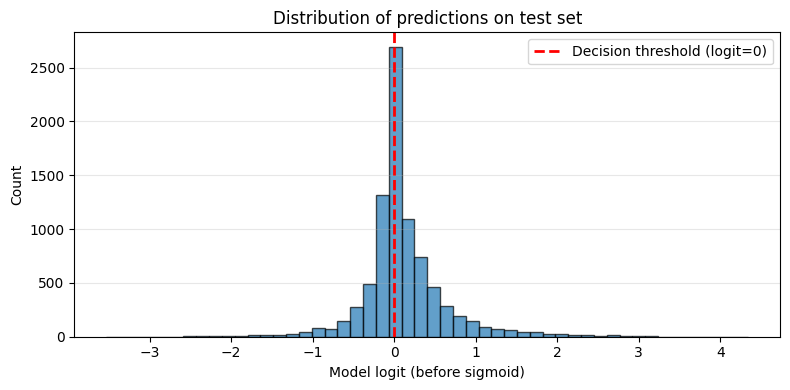


🔍 Sample mistakes (first 5):
  • Index 9: logit=-0.2869 → predicted REJECTED (wrong)
  • Index 13: logit=-0.0645 → predicted REJECTED (wrong)
  • Index 15: logit=-0.0737 → predicted REJECTED (wrong)
  • Index 17: logit=-0.7506 → predicted REJECTED (wrong)
  • Index 19: logit=-0.2644 → predicted REJECTED (wrong)

✅ Sample confident correct predictions (first 5):
  • Index 7: logit=1.2388 → predicted CHOSEN (correct, confident)
  • Index 10: logit=2.7687 → predicted CHOSEN (correct, confident)
  • Index 11: logit=1.2766 → predicted CHOSEN (correct, confident)
  • Index 12: logit=1.3230 → predicted CHOSEN (correct, confident)
  • Index 20: logit=1.4970 → predicted CHOSEN (correct, confident)


In [44]:
all_preds = []
all_logits = []
all_diffs = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)

        logits = model(features)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_logits.extend(logits.cpu().numpy())
        all_diffs.extend(features[:, -1].cpu().numpy())

# === Метрики ===

true_labels = np.ones(len(all_preds))
accuracy = accuracy_score(true_labels, all_preds)
auc = roc_auc_score(true_labels, all_logits)  # AUC по логитам

print(f"\nFINAL TEST RESULTS")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"ROC-AUC:   {auc:.4f}")
print(f"Total samples: {len(true_labels)}")
print(f"Baseline (LogReg on 1k): 0.6400")
print(f"{'='*50}")

#Конфузионная матрица
cm = confusion_matrix(true_labels, all_preds)
print(f"\nConfusion Matrix (predicted vs actual):")
print(f"                Predicted")
print(f"                Good   Bad")
print(f"Actual Good  [[  {int(cm[0][0]):5d}  {int(cm[0][1]):5d}  ]]")
print(f"       Bad   [[  {int(cm[1][0]):5d}  {int(cm[1][1]):5d}  ]]")

plt.figure(figsize=(8, 4))
plt.hist(all_logits, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Decision threshold (logit=0)')
plt.xlabel('Model logit (before sigmoid)')
plt.ylabel('Count')
plt.title('Distribution of predictions on test set')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()